### **Autor:** David Roca Tauste

---
---
# **📌ACTIVIDAD 1: CLASIFICAR CON SVM**
---
---

## CLASIFICADORES SVC CON DATOS SEPARABLES LINEALMENTE

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

a) Define el target y como compra y edad, salario como las predictoras X.

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
X = df[['edad', 'salario']]
y = df['compra']

semilla = 546
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=semilla)

print("Columnas del DataFrame:", df.columns)
print("Distribución original de y:", Counter(y))
print("Distribución de y_train:", Counter(y_train))
print("Distribución de y_test:", Counter(y_test))

Columnas del DataFrame: Index(['edad', 'salario', 'compra'], dtype='object')
Distribución original de y: Counter({0: 257, 1: 143})
Distribución de y_train: Counter({0: 177, 1: 103})
Distribución de y_test: Counter({0: 80, 1: 40})


b) Escala las características para usar SVM. Imprime máximo, mínimo y media de los valores escalados.

In [3]:
escalador = StandardScaler()
X_train_escalado = escalador.fit_transform(X_train)
X_test_escalado = escalador.transform(X_test)

print("X_train: min", X_train_escalado.min(axis=0), "max:", X_train_escalado.max(axis=0), "media:", X_train_escalado.mean(axis=0))
print("X_test: min", X_test_escalado.min(axis=0), "max:", X_test_escalado.max(axis=0), "media:", X_test_escalado.mean(axis=0))

X_train: min [-1.93084165 -1.56873923] max: [2.13336057 2.33735016] media: [-6.34413157e-17 -6.02692499e-17]
X_test: min [-1.93084165 -1.56873923] max: [2.13336057 2.30841616] media: [-0.09630593  0.05060005]


c) Crea un clasificador SVC con kernel="linear" y random_state al valor de las letras de tus apellidos. El resto de hiperparámetros se ignoran (valores por defecto).

In [4]:
clf = SVC(kernel='linear', random_state=semilla)
clf.fit(X_train_escalado, y_train)

SVC(kernel='linear', random_state=546)

d) Para validarlo muestra matriz de confusión, el informe de clasificación y la métrica usada en el entrenamiento que por defecto es accuracy.

In [5]:
y_pred = clf.predict(X_test_escalado)

print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))
print("Métrica usada para entrenar:")
print("Accuracy:", accuracy_score(y_test, y_pred))

Matriz de Confusión:
[[75  5]
 [10 30]]

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        80
           1       0.86      0.75      0.80        40

    accuracy                           0.88       120
   macro avg       0.87      0.84      0.85       120
weighted avg       0.87      0.88      0.87       120

Métrica usada para entrenar:
Accuracy: 0.875


e) Ahora haz un gráfico que muestre en el train y el test la frontera de decisión. Debes obtener algo similar a esto (en la unidad tienes diferentes listados de como conseguirlos). Define una función plot_frontera_decision(clasificador, X, y, escalador=None, titulo="").

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_frontera_decision(clasificador, X, y, escalador=None, titulo=""):
    if escalador is not None:
        X_orig = escalador.inverse_transform(X)
    else:
        X_orig = X

    X1_min, X1_max = X_orig[:, 0].min() - 1, X_orig[:, 0].max() + 1
    X2_min, X2_max = X_orig[:, 1].min() - 1, X_orig[:, 1].max() + 1

    x1_vals = np.linspace(X1_min, X1_max, 500)
    x2_vals = np.linspace(X2_min, X2_max, 500)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    puntos = np.array([X1.ravel(), X2.ravel()]).T

    if escalador is not None:
        puntos_escalados = escalador.transform(puntos)
        predicciones = clasificador.predict(puntos_escalados)
    else:
        predicciones = clasificador.predict(puntos)

    predicciones = predicciones.reshape(X1.shape)

    plt.contourf(X1, X2, predicciones, alpha=0.75, cmap=plt.cm.coolwarm)
    plt.scatter(X_orig[:, 0], X_orig[:, 1], c=y, cmap=ListedColormap(('blue', 'orange')), edgecolors='k')
    plt.xlabel('Edad')
    plt.ylabel('Salario')
    plt.title(titulo)

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


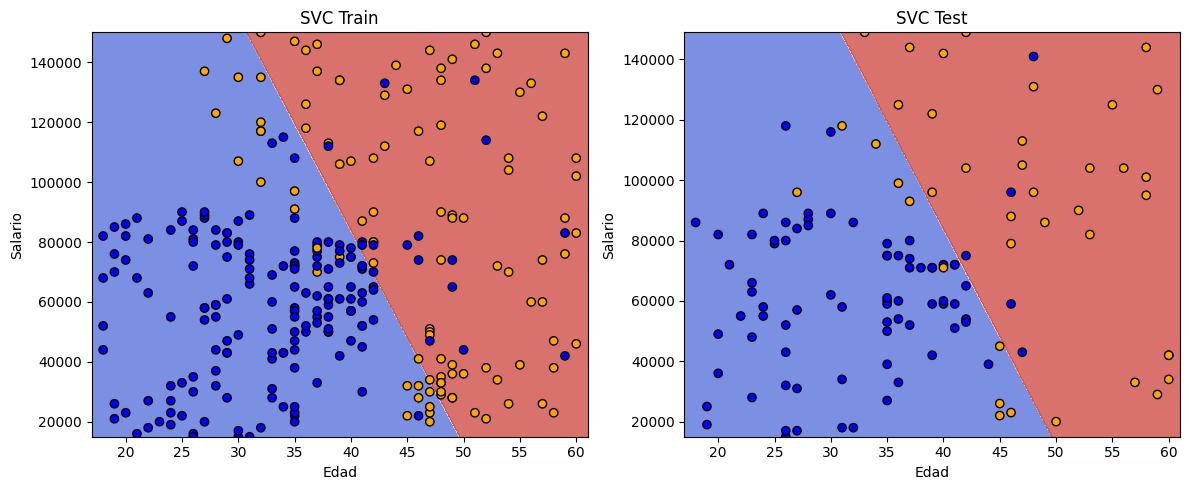

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_frontera_decision(clf, X_train_escalado, y_train, escalador=escalador, titulo="SVC Train")

plt.subplot(1, 2, 2)
plot_frontera_decision(clf, X_test_escalado, y_test, escalador=escalador, titulo="SVC Test")

plt.tight_layout()
plt.show()

f) Por último hacemos una función plot_curva_roc(clf, X_test, y_test) que defina y dibuje la curva ROC y muestre el AUC. Tienes ejemplos de código en la unidad 2. Ten en cuenta además que hay modelos clasificadores (argumento clf) que tienen el método predict_proba(X_test) y otros que no lo tienen y en su lugar puedes usar decision_function(X_test). Para saberlo tienes el método hasattr(clf,"predict_proba"): que pudes utilizar en un if. Una vez que lo tengas solo tienes que pedir ambas cosas y graficar el resultado:

In [8]:
from sklearn import metrics

def plot_curva_roc(clf, X_test, y_test):
    if hasattr(clf, "predict_proba"):
        y_scores = clf.predict_proba(X_test)[:, 1]
    else:
        y_scores = clf.decision_function(X_test)

    # Calcular curva ROC y AUC
    fpr, tpr, _ = metrics.roc_curve(y_test, y_scores)
    roc_auc = metrics.auc(fpr, tpr)

    # Graficar curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatorio')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

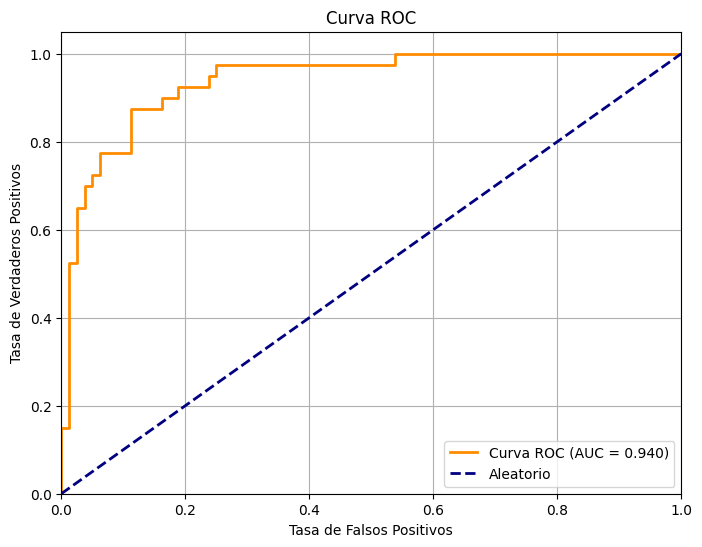

In [9]:
plot_curva_roc(clf, X_test_escalado, y_test)

## ENTREGA 1:
### a) Completa el código de los diferentes apartados y entrega resultado de su ejecución.
Se encuentra arriba.

### b) No es un mal resultado pero tampoco es muy bueno. Hemos entrenado un modelo asumiendo que los datos son linealmente separables. Si revisas los gráficos que has generado quizás puedas confirmarlo o desmentirlo. Hazlo y dime:
- ¿Qué gráfico te ha convencido? (indica el apartado)<br>
Me ha convencido el gráfico de frontera de decisión.

- ¿De qué te ha convencido? De que son separables o de que no lo son:<br>
Me ha convencido de que no son del todo separables, ya que hay varios datos que se ubican en el lado incorrecto de la frontera.

---
## CLASIFICADORES SVC CON DATOS NO SEPARABLES LINEALMENTE

a) Vamos a definir en un diccionario diferentes clasificadores SVM que usen diferentes tipos de kernel. Realizamos la importación de elementos y creamos el diccionario.

In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.svm import SVC, NuSVC

# Definir clasificadores con diferentes kernels
clasificadores = {
    "SVC (RBF)": SVC(kernel="rbf", C=1000, gamma=0.1),
    "SVC (Polynomial)": SVC(kernel="poly", degree=3, C=1000, gamma='scale'),
    "SVC (Sigmoid)": SVC(kernel="sigmoid", C=1000, gamma='scale'),
    "NuSVC": NuSVC()
}

b) En un bucle vamos a utilizar validación cruzada para buscar el mejor score como la media de scores de 5-folds. modelos que C informe de clasificación y la métrica usada en el entrenamiento que por defecto es accuracy.

(SVC (RBF)): Precisión media = 0.9000 | Desviación estándar = 0.0350


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


(SVC (Polynomial)): Precisión media = 0.8607 | Desviación estándar = 0.0134


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


(SVC (Sigmoid)): Precisión media = 0.6821 | Desviación estándar = 0.0262


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


(NuSVC): Precisión media = 0.8964 | Desviación estándar = 0.0286


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Mejor clasificador: SVC (RBF) con una precisión media de 0.9000


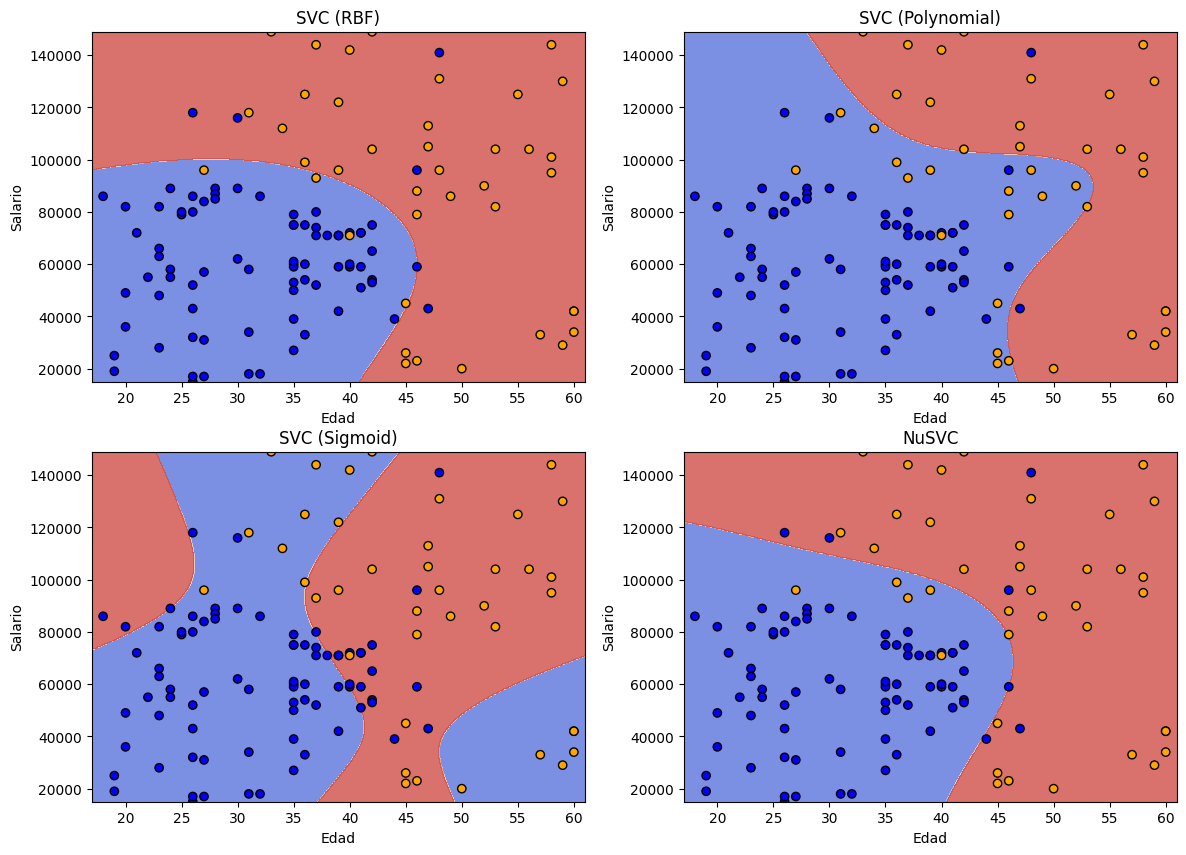

In [11]:
# Evaluar y encontrar el mejor clasificador
resultados = {}
nombre_mejor_modelo = ""
mejor_score = 0
loseta_del_grafico = 1
plt.figure(figsize=(14, 10))

for Nombre, clf in clasificadores.items():
    scores = cross_val_score(clf, X_train_escalado, y_train, cv=5, scoring="accuracy")
    media_de_scores = scores.mean()
    resultados[Nombre] = scores
    print(
        f"({Nombre}): Precisión media = {media_de_scores:.4f} | Desviación estándar = {scores.std():.4f}"
    )
    plt.subplot(2, 2, loseta_del_grafico)
    loseta_del_grafico += 1
    clf.fit(
        X_train_escalado, y_train
    )  # Entrenamiento real (validacion cruzada no entrena)
    plot_frontera_decision(
        clasificador=clf,
        X=X_test_escalado,
        y=y_test,
        escalador=escalador,
        titulo=Nombre,
    )
    if media_de_scores > mejor_score:
        mejor_score = media_de_scores
        nombre_mejor_modelo = Nombre


print(f"\nMejor clasificador: {nombre_mejor_modelo} con una precisión media de {mejor_score:.4f}")

## ENTREGA 2:
### a) Completa el código de los diferentes apartados y entrega resultado de su ejecución (recuerda modificar ramdom_state a tu semilla personal).
Se encuentra arriba.

### b) En la línea 27 del código que aparece en el apartado b), se vuelve a entrenar el clasificador de la iteración ¿Es necesario? ¿No queda entrenado al llamar antes a cross_val_score()?
Sí es necesario hacerlo porque cross_val_score() no devuelve el clasificador entrenado, solamente lo entrena para realizar los cálculos del método.

### c) Añade otro gráfico donde aparezcan las curvas ROC con el valor AUC de los diferentes clasificadores.

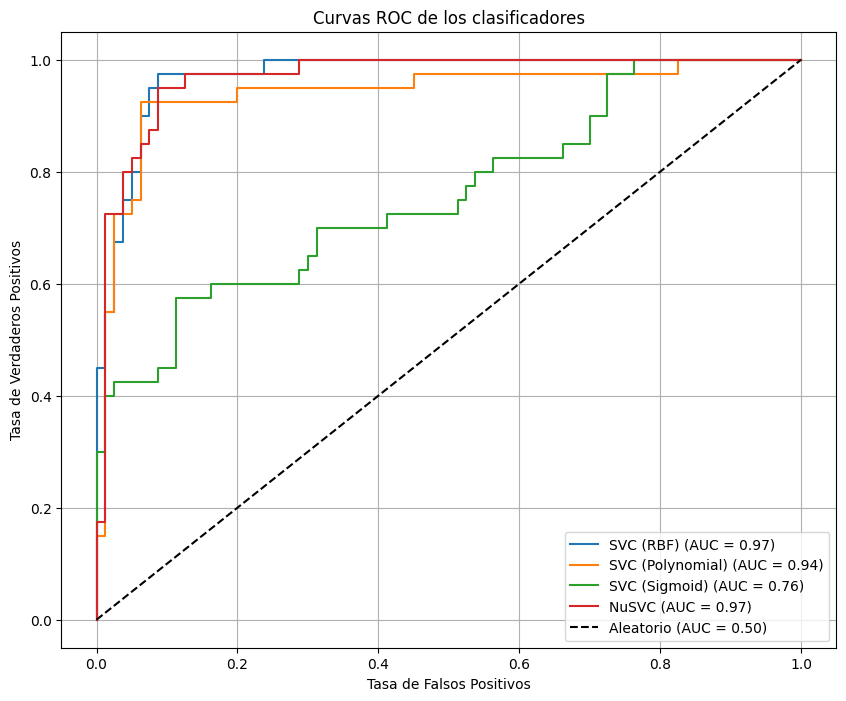

In [12]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for nombre, clf in clasificadores.items():
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test_escalado)[:, 1]
    else:
        y_score = clf.decision_function(X_test_escalado)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {roc_auc:.2f})")


plt.plot([0, 1], [0, 1], "k--", label="Aleatorio (AUC = 0.50)")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curvas ROC de los clasificadores")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### d) Intenta mejorar el desempeño de los clasificadores afinando los hiperparámetros de cada modelo que hay en el diccionario de clasificadores copiando el código en una nueva celda a continuación y mostrando su ejecución incluidos los gráficos.


Buscando mejores hiperparámetros para: SVC (RBF)
(SVC (RBF)): Precisión media = 0.9107 | Desviación estándar = 0.0299
Mejores parámetros encontrados: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Buscando mejores hiperparámetros para: SVC (Polynomial)
(SVC (Polynomial)): Precisión media = 0.8607 | Desviación estándar = 0.0134
Mejores parámetros encontrados: {'C': 100, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Buscando mejores hiperparámetros para: SVC (Sigmoid)
(SVC (Sigmoid)): Precisión media = 0.7179 | Desviación estándar = 0.0381
Mejores parámetros encontrados: {'C': 1, 'gamma': 'scale', 'kernel': 'sigmoid'}


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Buscando mejores hiperparámetros para: NuSVC
(NuSVC): Precisión media = 0.9000 | Desviación estándar = 0.0331
Mejores parámetros encontrados: {'gamma': 'scale', 'kernel': 'rbf', 'nu': 0.3}


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Mejor clasificador: SVC (RBF) con una precisión media de 0.9107


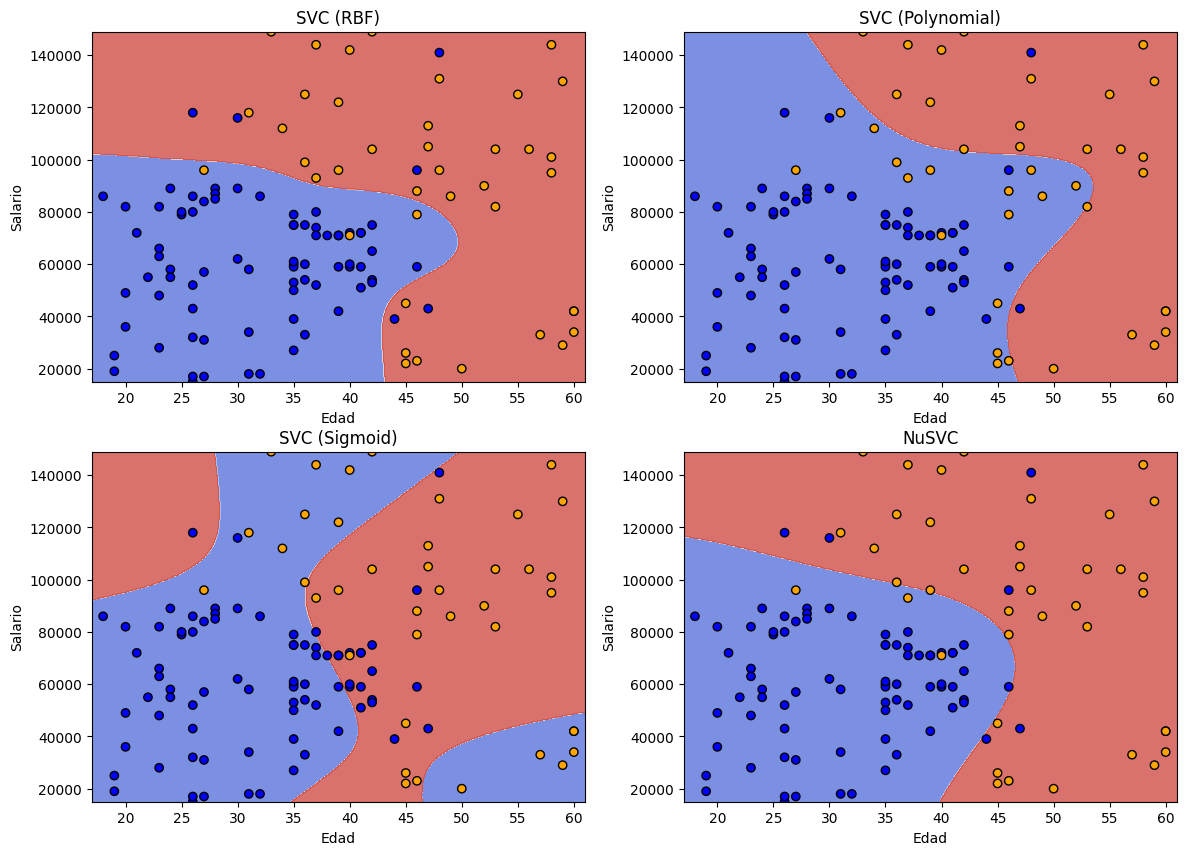

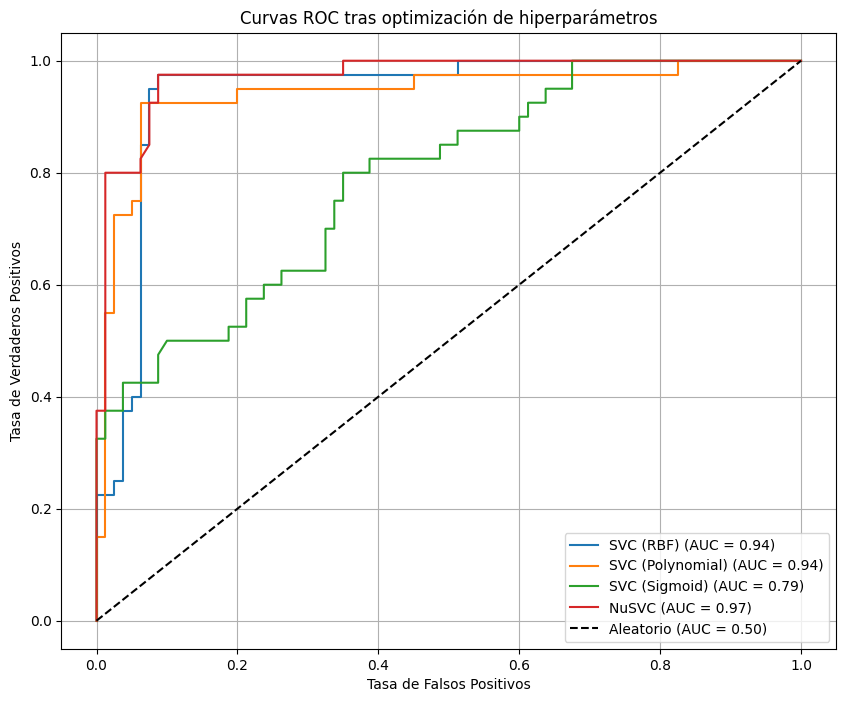

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "SVC (RBF)": {
        "kernel": ["rbf"],
        "C": [1, 10, 100, 1000],
        "gamma": [0.001, 0.01, 0.1, 1],
    },
    "SVC (Polynomial)": {
        "kernel": ["poly"],
        "C": [1, 10, 100, 1000],
        "degree": [2, 3, 4],
        "gamma": ["scale", "auto"],
    },
    "SVC (Sigmoid)": {
        "kernel": ["sigmoid"],
        "C": [1, 10, 100, 1000],
        "gamma": ["scale", "auto"],
    },
    "NuSVC": {
        "nu": [0.1, 0.3, 0.5],
        "kernel": ["rbf", "sigmoid"],
        "gamma": ["scale", "auto"],
    },
}

clasificadores_base = {
    "SVC (RBF)": SVC(probability=True),
    "SVC (Polynomial)": SVC(probability=True),
    "SVC (Sigmoid)": SVC(probability=True),
    "NuSVC": NuSVC(probability=True),
}

mejores_modelos = {}
resultados = {}
nombre_mejor_modelo = ""
mejor_score = 0

loseta_del_grafico = 1
plt.figure(figsize=(14, 10))

for nombre, clf in clasificadores_base.items():
    print(f"\nBuscando mejores hiperparámetros para: {nombre}")
    grid = GridSearchCV(clf, param_grid[nombre], cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train_escalado, y_train)

    mejor_modelo = grid.best_estimator_
    mejores_modelos[nombre] = mejor_modelo

    scores = cross_val_score(
        mejor_modelo, X_train_escalado, y_train, cv=5, scoring="accuracy"
    )
    media_de_scores = scores.mean()
    resultados[nombre] = scores

    print(
        f"({nombre}): Precisión media = {media_de_scores:.4f} | Desviación estándar = {scores.std():.4f}"
    )
    print(f"Mejores parámetros encontrados: {grid.best_params_}")

    plt.subplot(2, 2, loseta_del_grafico)
    loseta_del_grafico += 1
    mejor_modelo.fit(X_train_escalado, y_train)
    plot_frontera_decision(
        clasificador=mejor_modelo,
        X=X_test_escalado,
        y=y_test,
        escalador=escalador,
        titulo=nombre,
    )

    if media_de_scores > mejor_score:
        mejor_score = media_de_scores
        nombre_mejor_modelo = nombre

print(
    f"\nMejor clasificador: {nombre_mejor_modelo} con una precisión media de {mejor_score:.4f}"
)

# Curva ROC
plt.figure(figsize=(10, 8))

for nombre, modelo in mejores_modelos.items():
    y_score = modelo.predict_proba(X_test_escalado)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Aleatorio (AUC = 0.50)")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curvas ROC después de la optimización de hiperparámetros")
plt.legend(loc="lower right")
plt.grid()
plt.show()

---
## CLASIFICADORES SVC CON DATOS NO BALANCEADOS

a) Crea de manera sintética unos 1000 datos desbalanceados de 20 características, con 2 clases (el 90% de ejemplos es de una) y el otro 10% es de la otra clase usando tu propia semilla aleatoria personal.

In [ ]:
# Crear un conjunto de datos desbalanceado
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

# Crear dataset desbalanceado
semilla = 546
X, y = make_classification(n_classes=2, weights=[0.9, 0.1], n_samples=1000, random_state=semilla)

b) Dividir los datos en 2 particiones train y test con el 30% de datos para test y usando tu semilla aleatoria. Clasifica de manera normal estos datos con un clasificador SVC(kernel='rbf', random_state=449) y luego imprime un informe de los resultados que obtienes con los datos de validación clasification_report(y_test, y_pred).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=semilla)

clf = SVC(kernel='rbf', random_state=semilla)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       272
           1       0.67      0.43      0.52        28

    accuracy                           0.93       300
   macro avg       0.80      0.70      0.74       300
weighted avg       0.92      0.93      0.92       300



c) Ponderar las clases con pesos: ahora repetimos el mismo código pero añadimos el parámetro class_weight="balanced" cuando creamos el clasificador SVC. Vuelve a entrenar, genera predicciones e imprime el informe de clasificación. Indica donde hay mejora respecto del caso b).

In [ ]:
clf = SVC(kernel="rbf", random_state=semilla, class_weight="balanced")
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       272
           1       0.62      0.71      0.67        28

    accuracy                           0.93       300
   macro avg       0.80      0.84      0.81       300
weighted avg       0.94      0.93      0.94       300



Después de entrenar el clasificador SVC con el parámetro class_weight="balanced", he observado principalmente una mejora significativa en las métricas de la clase 1. También han mejorado las métricas: 'macro avg' y 'weighted avg'.

d) Balanceo con SMOTE: aplica SMOTE solo en el conjunto de entrenamiento para evitar fuga de datos. Copia otra vez el código del apartado b) y al principio importa el objeto SMOTE: from imblearn.over_sampling import SMOTE (quizás tengas que instalar).

In [5]:
# Balanceo con SMOTE
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=semilla)

# Aplicar SMOTE para sobre-samplear la clase minoritaria
smote = SMOTE(sampling_strategy='auto', random_state=semilla)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Modelo
clf = SVC(kernel='rbf', random_state=semilla)
clf.fit(X_resampled, y_resampled)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       272
           1       0.67      0.57      0.62        28

    accuracy                           0.93       300
   macro avg       0.81      0.77      0.79       300
weighted avg       0.93      0.93      0.93       300



Después de aplicar SMOTE, he observado que tanto las métricas de la clase 1 como la métrica 'macro avg' han mejorado.

e) Ejemplo de Balanceo manual con resampleo: copia de nuevo el código del apartado b) y al principio importa: from sklearn.utils import resample. Tras hacer la partición en train y test, haz que la cantidad de filas de la clase minoritaria coincida con la cantidad de filas de la mayoritaria con el siguiente código:

In [ ]:
from sklearn.utils import resample

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=semilla)

# Dividir en clases
X_mayoritaria = X_train[y_train == 0]
X_minoritaria = X_train[y_train == 1]

# Duplicar la clase minoritaria
X_minoritaria_aumentada = resample(X_minoritaria, replace=True, n_samples=len(X_minoritaria), random_state=semilla)
y_minoritaria = [0] * len(X_mayoritaria)
y_minoritaria_aumentada = [1] * len(X_minoritaria_aumentada)

# Crear nuevo dataset balanceado
X_balanceado = np.vstack((X_mayoritaria, X_minoritaria_aumentada))
y_balanceado = np.array(y_minoritaria + y_minoritaria_aumentada)

# Modelo
clf = SVC(kernel='rbf', random_state=semilla)
clf.fit(X_balanceado, y_balanceado)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       272
           1       0.54      0.25      0.34        28

    accuracy                           0.91       300
   macro avg       0.73      0.61      0.65       300
weighted avg       0.89      0.91      0.89       300



Después de aplicar el balanceo manual con resampleo, he observado que las métricas han empeorado de manera general.

f) Cambiar el umbral de decisión: copia una vez más el código del apartado b). Tras particionar, cuando se va a crear el modelo SVC debes añadir el parámetro probability=True porque necesitamos las probabilidades de pertenencia a cada clase. Entrena al modelo normalmente. Luego haz una predicción de las probabilidades de la clase minoritaria con la sentencia: y_prob = svc.predict_proba(X_test)[:, 1]. Ahora cambia estas predicciones bajando el umbral para favorecer a la clase minoritaria (en este caso la 1):

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=semilla)

clf = SVC(kernel='rbf', random_state=semilla, probability=True)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Reporte con umbral por defecto (0.5):")
print(classification_report(y_test, y_pred))

y_prob = clf.predict_proba(X_test)[:, 1]
umbral = 0.3
y_limite_pred = (y_prob > umbral).astype(int)

print(f"\nReporte con umbral ajustado ({umbral}):")
print(classification_report(y_test, y_limite_pred))

Reporte con umbral por defecto (0.5):
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       272
           1       0.67      0.43      0.52        28

    accuracy                           0.93       300
   macro avg       0.80      0.70      0.74       300
weighted avg       0.92      0.93      0.92       300


Reporte con umbral ajustado (0.3):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       272
           1       0.63      0.61      0.62        28

    accuracy                           0.93       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.93      0.93      0.93       300



Tras cambiar el umbral de decisión a 0.3, he observado que las métricas de la clase 1 han mejorado, excepto la precisión.

---
## CLASIFICAR MNIST

a) Primero cargamos el dataset y luego lo particionamos dando el 20% para test y usando tu semilla aleatoria. Te paso la parte de la carga de los datos.

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

# Cargar datos
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

X = mnist["data"]
X = X[:800]

y = mnist["target"].astype(np.uint8)
y = y[:800]

In [2]:
semilla = 546
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=semilla)

print(len(X_train))
print(len(X_test))

640
160


b) Comenzamos con un clasificador SVM lineal sencillo. Crea un objeto LinearSVC al que llamas clf_1 indicando tu semilla aleatoria y un máximo de 200 iteraciones y lo entrenas con X_train_pruebas = X[0:600] y con y_train_pruebas = y[0:600].

In [3]:
from sklearn.svm import LinearSVC

clf_1 = LinearSVC(random_state=semilla, max_iter=200)
clf_1.fit(X_train, y_train)

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(max_iter=200, random_state=546)

c) Medir su desempeño. Primero creamos X_test_pruebas= X[600:800] e y_test_pruebas= y[600:800]. Hacemos predicciones y medimos el accuracy (que será una estimación del real). Por ahora vemos si tenemos underfitting (un puntaje malo de la métrica). Yo obtengo 0.76, no está mal para tan pocos datos. Pero posiblemente sea mejorable.

In [4]:
from sklearn.metrics import accuracy_score

y_pred_1 = clf_1.predict(X_test)
accuracy_1 = accuracy_score(y_test, y_pred_1)
print(f"Accuracy LinearSVC sin escalar: {accuracy_1:.2f}")

Accuracy LinearSVC sin escalar: 0.83


d) Intentamos mejorar la métrica normalizando los datos con estas sentencias antes de dárselos a un nuevo LinearSVC llamado clf_2.

In [5]:
from sklearn.preprocessing import StandardScaler

s_train = StandardScaler()
X_train_escalado = s_train.fit_transform(X_train.astype(np.float32))
X_test_escalado = s_train.transform(X_test.astype(np.float32))

clf_2 = LinearSVC(random_state=semilla, max_iter=200)
clf_2.fit(X_train_escalado, y_train)

y_pred_2 = clf_2.predict(X_test_escalado)
accuracy_2 = accuracy_score(y_test, y_pred_2)
print(f"Accuracy LinearSVC con datos normalizados: {accuracy_2:.2f}")

Accuracy LinearSVC con datos normalizados: 0.78


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


e) Cambio de clasificador: copio el código del apartado anterior a una nueva celda del notebook previamente etiquetada con el texto de este apartado. En el código lo único que cambia es el modelo al que llamamos clf_3 y su importación. Le indicamos de hiperparámetros además de nuestro random_state y un número de iteraciones de 200 el gamma="scale". Lo entrenamos y lo validamos. Ahora vuelvo a obtener el mismo puntaje que al inicio: 0.76

In [6]:
from sklearn.svm import SVC

clf_3 = SVC(kernel='rbf', gamma='scale', C=1.0, max_iter=200, random_state=semilla)
clf_3.fit(X_train_escalado, y_train)

y_pred_3 = clf_3.predict(X_test_escalado)
accuracy_3 = accuracy_score(y_test, y_pred_3)
print(f"Accuracy SVC con kernel RBF: {accuracy_3:.2f}")

Accuracy SVC con kernel RBF: 0.82


f) Mejorar la métrica cambiando hiperparámetros: ¿Qué hiperparámetros? ¿Cuales son sus mejores valores? Los más influyentes son C y gamma. Si no tenemos una intuición a priori de cuales serían los posibles valores adecuados, podemos utilizar una búsqueda aleatoria que nos oriente. En una nueva celda del notebook haz estas importaciones.

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import reciprocal, uniform

# La dist. recíproca escoge valores con la misma prob. en escala logarítmica
# - En rangos de diferentes escalas como [0.001 a 20] P(coger 0.015) == P(coger 0.15) == P(coger 1.5) == P(coger 15)
# - Se usa cuando el parámetro afecta exponencialmente al modelo.
# La dist. uniforme todos los valores tienen la misma prob.
# - Se usa cuando el valor del parámetro afecta linealmente al modelo.
distribuciones_de_parametros = {"gamma": reciprocal(0.001, 10), "C": uniform(1, 20)}

clf_base = SVC(kernel="rbf", random_state=semilla)
cv_aleatoria = RandomizedSearchCV(
    clf_base,
    param_distributions=distribuciones_de_parametros,
    n_iter=40,
    verbose=1,
    cv=3,
    random_state=semilla,
)
cv_aleatoria.fit(X_train_escalado, y_train)

print("Mejor configuración:", cv_aleatoria.best_estimator_)
print("Mejor score:", cv_aleatoria.best_score_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Mejor configuración: SVC(C=np.float64(9.15729460196556), gamma=np.float64(0.0016404355035795919),
    random_state=546)
Mejor score: 0.8375455223553158


g) Mejorar la métrica buscando configuraciones indicadas: con la información obtenida en la búsqueda aleatoria creamos un grid search en otra celda dando 5 o 7 posibles valores a cada hiperparámetro. El valor indicado en la búsqueda aleatoria puede utilizarse como valor máximo o como mínimo o como valor central. Yo voy a crearme un diccionario con los posibles valores de cada hiperparámetro {"hp1":[v1, v2...], "hp2":[v1, v2...]} y construyo un objeto GridSearchCV() con el que probar la mejor combinación. Luego imprimo la mejor configuración y el score que se obtiene con ella en el conjunto de prueba ya escalado (recuerda que usamos un 1% de los datos train, así que en realidad es una estimación de si mejoro o no):

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.1, 1, 10, 50, 100], "gamma": [0.0001, 0.001, 0.01, 0.1]}

grid_search = GridSearchCV(
    SVC(kernel="rbf", random_state=semilla), param_grid, cv=3, verbose=1
)
grid_search.fit(X_train_escalado, y_train)

print("Mejor estimador:", grid_search.best_estimator_)
print("Mejor score:", grid_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejor estimador: SVC(C=50, gamma=0.0001, random_state=546)
Mejor score: 0.8750530180041829


h) Con esta configuración entreno: cojo de X_train= X[0:60000,:] todas las columnas de las primeras 60 mil muestras, en X_test=X[60000:, :] las 10 mil para test, y_train=y[0:60000] las 60000 muestras de test y en y_test=y[60000:] las 10000 para test

Al final he hecho el entrenamiento con menos datos porque con el dataset completo no terminaba nunca.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

X = mnist["data"]
y = mnist["target"].astype(np.uint8)

X_train = X[0:1000].astype(np.float32)
y_train = y[0:1000]
X_test = X[1000:1200].astype(np.float32)
y_test = y[1000:1200]

detector_digitos = Pipeline(
    [
        ("escalado", StandardScaler()),
        (
            "clasificador",
            SVC(
                kernel="rbf",
                C=grid_search.best_params_["C"],
                gamma=grid_search.best_params_["gamma"],
                random_state=semilla,
                probability=True
            ),
        )
    ]
)

detector_digitos.fit(X_train, y_train)
y_pred_final = detector_digitos.predict(X_test)

print("Accuracy de detector_digitos:", accuracy_score(y_test, y_pred_final))
print("\nInforme de clasificación:\n", classification_report(y_test, y_pred_final))

Accuracy de detector_digitos: 0.825

Informe de clasificación:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.90      0.96      0.93        27
           2       0.64      0.80      0.71        20
           3       0.85      0.61      0.71        18
           4       0.81      0.88      0.84        24
           5       0.47      0.67      0.55        12
           6       1.00      0.75      0.86        16
           7       0.90      0.76      0.83        25
           8       0.83      0.88      0.86        17
           9       0.91      0.95      0.93        21

    accuracy                           0.82       200
   macro avg       0.83      0.81      0.81       200
weighted avg       0.85      0.82      0.83       200



i) Guarda el modelo en un fichero: Si tu modelo obtiene un accuracy superior al 95% y no tiene peores el resto de métricas de clasificación, guarda en un fichero de disco el objeto de una de estas 2 maneras y con el nombre "detecta_digit_<tus_iniciales>" y diferente extensión según la forma de guardarlo que elijas.

In [10]:
import joblib

# Guardar modelo
joblib.dump(detector_digitos, "detecta_digit_davroctau.joblib")

['detecta_digit_davroctau.joblib']

j) Aplicación de escritorio: hacemos una pequeña aplicación de escritorio que nos permita escribir en pantalla con el ratón y nos diga el número que hemos escrito.

In [19]:
import tkinter as tk
from tkinter import messagebox
import joblib
import numpy as np
from PIL import Image, ImageDraw, ImageOps

# Cargar el modelo SVC que espera un array de 784 características que ya escaladas
modelo = joblib.load('detecta_digit_davroctau.joblib')
print("Soporte de clases:", modelo.classes_) # Comprobar clases 0-9

# Crear la interfaz gráfica con Tkinter
class App(tk.Tk):
    def __init__(self):
        super().__init__()
        self.title("Reconocer Números Dibujados")
        self.geometry("400x500")

        # Lienzo para dibujar
        self.canvas = tk.Canvas(self, width=280, height=280, bg='white', cursor="cross")
        self.canvas.pack(pady=10)
        self.canvas.bind("<B1-Motion>", self.dibujar)

        # Imagen para almacenar el dibujo
        self.image = Image.new("L", (280, 280), color=255) # Fondo blanco, escala de grises
        self.draw = ImageDraw.Draw(self.image)

        # Botones
        tk.Button(self, text="Predecir", command=self.predecir).pack(pady=5)
        tk.Button(self, text="Limpiar", command=self.limpiar).pack(pady=5)

        # Eventos de dibujo
        # self.canvas.bind("<B1-Motion>", self.dibujar) # Ya se incluyó al inicio

    def dibujar(self, event):
        x, y = event.x, event.y
        radio = 8 # Grosor del trazo
        self.canvas.create_oval(x - radio, y - radio, x + radio, y + radio, fill='black', outline='black')
        # Escalar al tamaño de la imagen de 64x64 y dibujar sobre ella
        escala_x = int(x * (64 / 280))
        escala_y = int(y * (64 / 280))
        self.draw.ellipse((escala_x - 2, escala_y - 2, escala_x + 2, escala_y + 2), fill=0)

    def predecir(self):
        # self.image.save("dibujo.png") # Para guardar y revisar el dibujo
        imagen_convertida = self.image.resize((28, 28)).convert('L') # Centrar y convertir a 28x28 (escala de grises)
        if imagen_convertida is None:
            messagebox.showinfo("Predicción", "No se ha escrito nada")
        else:
            imagen_array = np.array(imagen_convertida).astype('float32') / 255.0 # No dividir si usas StandardScaler
            imagen_array = imagen_array.reshape(1, -1) # "aplanar" la imagen
            prediccion = modelo.predict(imagen_array)
            prediccion_proba = modelo.predict_proba(imagen_array)
            messagebox.showinfo("Predicción", f"Número detectado: {prediccion[0]}\nPuntajes: {prediccion_proba[0].round(2)}")

    def limpiar(self):
        self.canvas.delete("all")
        self.image = Image.new("L", (280, 280), color=255)
        self.draw = ImageDraw.Draw(self.image)
        self.canvas.create_rectangle(0, 0, 64, 64, fill="white") # Para asegurar un fondo blanco inicial

    def centrar_y_convertir_a_28x28(self, imagen_original):
        imagen_invertida = ImageOps.invert(imagen_original) # invertir imagen
        imagen_28x28 = imagen_invertida.resize((28, 28), Image.LANCZOS) # A 28x28
        return np.array(imagen_28x28, dtype=np.uint8).flatten().reshape(1, -1)

if __name__ == "__main__":
    app = App()
    app.mainloop()

Soporte de clases: [0 1 2 3 4 5 6 7 8 9]


## ENTREGA 3:
### a) Completa los apartados del a) al j) entregando código y resultados de ejecución.
Se encuentra arriba.

### b) ¿Qué ocurre si aumentas el trazo del programa de prueba del reconocimiento de números? ¿Y si lo disminuyes? Aumenta a 10 y prueba a ver si te reconoce los números del 0 al 9. ¿Mejora, empeora o es indiferente? Disminuye a 4 y vuelve a repetir la prueba. ¿Afecta o no al desempeño? ¿A qué puede deberse?
Si aumento el trazo a 10, el reconocimiento mejora porque puede detectar más patrones.<br>
Si disminuyo el trazo a 4, el reconocimiento empeora porque la imagen pierde resolución.